Step 1 — Load German Credit + Add Borrower‑Level Micro‑Features

In [3]:
import pandas as pd

# Load UCI German Credit dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    "status",                # A11–A14
    "duration",              # numeric
    "credit_history",        # A30–A34
    "purpose",               # A40–A49
    "credit_amount",         # numeric
    "savings",               # A61–A65
    "employment",            # A71–A75
    "installment_rate",      # numeric
    "personal_status_sex",   # A91–A95
    "other_debtors",         # A101–A103
    "residence_since",       # numeric
    "property",              # A121–A124
    "age",                   # numeric
    "other_installment_plans", # A141–A143
    "housing",               # A151–A153
    "number_credits",        # numeric
    "job",                   # A171–A174
    "people_liable",         # numeric
    "telephone",             # A191–A192
    "foreign_worker",        # A201–A202
    "target"                 # 1 = good, 2 = bad
]

df = pd.read_csv(url, sep=" ", header=None, names=columns)

# Convert target to binary: 1 = good (eligible), 0 = bad (not eligible)
df["target"] = (df["target"] == 1).astype(int)

df.head()


,status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,0
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,0


STEP 2 — Borrower‑Level Micro‑Features

In [4]:
# Financial ratios
df["loan_to_duration"] = df["credit_amount"] / df["duration"]
df["loan_to_age"] = df["credit_amount"] / df["age"]
df["installment_burden"] = df["installment_rate"] * df["credit_amount"]

# Risk flags
df["is_young_borrower"] = (df["age"] < 25).astype(int)
df["is_high_amount"] = (df["credit_amount"] > df["credit_amount"].median()).astype(int)
df["is_short_employment"] = df["employment"].isin(["A71"]).astype(int)

# Purpose risk score
risk_map = {
    "A40": 3, "A41": 3, "A42": 3,
    "A43": 2, "A44": 2,
    "A45": 1, "A46": 1
}
df["purpose_risk"] = df["purpose"].map(risk_map).fillna(2)

# Binned features
df["age_bin"] = pd.cut(df["age"], bins=[18,25,35,50,100], labels=[1,2,3,4])
df["duration_bin"] = pd.cut(df["duration"], bins=[0,12,24,48,100], labels=[1,2,3,4])
df["credit_amount_bin"] = pd.qcut(df["credit_amount"], q=4, labels=[1,2,3,4])

# Interaction features
df["duration_x_amount"] = df["duration"] * df["credit_amount"]
df["age_x_employment"] = df["age"] * df["employment"].astype("category").cat.codes


STEP 3 — Add Synthetic Monthly Timestamps

In [5]:
df["synthetic_date"] = pd.date_range(start="2015-01-01", periods=len(df), freq="M")


C:\Users\Kiran\AppData\Local\Temp\ipykernel_24676\3424298247.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df["synthetic_date"] = pd.date_range(start="2015-01-01", periods=len(df), freq="M")


STEP 4 — Add FRED Credit‑Condition Features

In [6]:
import pandas_datareader.data as web

fred_series = {
    "fred_total_credit": "TOTALSL",
    "fred_revolving_credit": "REVOLSL",
    "fred_nonrevolving_credit": "NONREVSL",
    "fred_auto_loan_rate": "TERMCBAUTO48NS",
    "fred_credit_card_rate": "TERMCBCCALLNS"
}

fred_df = pd.DataFrame()

for name, code in fred_series.items():
    fred_df[name] = web.DataReader(code, "fred", start="2010-01-01")

# Growth rates
fred_df["fred_total_credit_growth"] = fred_df["fred_total_credit"].pct_change()
fred_df["fred_revolving_growth"] = fred_df["fred_revolving_credit"].pct_change()
fred_df["fred_nonrevolving_growth"] = fred_df["fred_nonrevolving_credit"].pct_change()


STEP 5 — Add CFPB Mortgage + Auto Origination Features

In [7]:
import pandas as pd

# -----------------------------
# STEP 5 — Load CFPB Macro Data (Safe Version)
# -----------------------------

# AUTO LOANS
auto = pd.read_csv(
    "https://raw.githubusercontent.com/cfpb/consumer-credit-trends-data/main/auto-loans/vol_data_AUT.csv"
)

auto["date"] = pd.to_datetime(auto["date"])

# Rename volume column
auto = auto.rename(columns={"vol": "cfpb_auto_orig_volume"})

# Handle YoY column safely
if "vol_yoy" in auto.columns:
    auto = auto.rename(columns={"vol_yoy": "cfpb_auto_orig_yoy"})
else:
    # Compute YoY manually if missing
    auto = auto.sort_values("date")
    auto["cfpb_auto_orig_yoy"] = auto["cfpb_auto_orig_volume"].pct_change(12)

# MORTGAGES
mort = pd.read_csv(
    "https://raw.githubusercontent.com/cfpb/consumer-credit-trends-data/main/mortgages/vol_data_MTG.csv"
)

mort["date"] = pd.to_datetime(mort["date"])

mort = mort.rename(columns={"vol": "cfpb_mort_orig_volume"})

if "vol_yoy" in mort.columns:
    mort = mort.rename(columns={"vol_yoy": "cfpb_mort_orig_yoy"})
else:
    mort = mort.sort_values("date")
    mort["cfpb_mort_orig_yoy"] = mort["cfpb_mort_orig_volume"].pct_change(12)

print("AUTO COLUMNS:", auto.columns.tolist())
print("MORT COLUMNS:", mort.columns.tolist())


AUTO COLUMNS: ['month', 'date', 'cfpb_auto_orig_volume', 'vol_unadj', 'cfpb_auto_orig_yoy']
MORT COLUMNS: ['month', 'date', 'cfpb_mort_orig_volume', 'vol_unadj', 'cfpb_mort_orig_yoy']


STEP 6 — Build Macro Stress Index + Merge Everything

In [8]:
# -----------------------------
# STEP 6 — Build Macro Stress Index + Merge
# -----------------------------

# Safety checks
required_auto_cols = ["cfpb_auto_orig_volume", "cfpb_auto_orig_yoy"]
required_mort_cols = ["cfpb_mort_orig_volume", "cfpb_mort_orig_yoy"]

for col in required_auto_cols:
    if col not in auto.columns:
        raise KeyError(f"Missing column in auto dataframe: {col}")

for col in required_mort_cols:
    if col not in mort.columns:
        raise KeyError(f"Missing column in mortgage dataframe: {col}")

# Build macro stress index aligned to FRED index
macro = pd.DataFrame(index=fred_df.index)

macro["macro_stress_index"] = (
    -fred_df["fred_total_credit_growth"].fillna(0) +
    -auto.set_index("date")["cfpb_auto_orig_yoy"].reindex(fred_df.index).fillna(0) +
    -mort.set_index("date")["cfpb_mort_orig_yoy"].reindex(fred_df.index).fillna(0)
)

macro_full = pd.concat([fred_df, macro], axis=1)

# Handle missing values in macro data before merging
macro_full = macro_full.fillna(method='ffill').fillna(0)

df = df.merge(
    macro_full,
    left_on="synthetic_date",
    right_index=True,
    how="left"
)

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (1000, 43)


C:\Users\Kiran\AppData\Local\Temp\ipykernel_24676\830910824.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  macro_full = macro_full.fillna(method='ffill').fillna(0)


,status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,synthetic_date,fred_total_credit,fred_revolving_credit,fred_nonrevolving_credit,fred_auto_loan_rate,fred_credit_card_rate,fred_total_credit_growth,fred_revolving_growth,fred_nonrevolving_growth,macro_stress_index
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,2015-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,2015-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,2015-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,2015-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,2015-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# STEP 7 — EXPLORATORY DATA ANALYSIS (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("Dataset Shape:", df.shape)
print("\nTarget Distribution:")
print(df['target'].value_counts())
print(f"\nClass Balance: {df['target'].mean():.2%} good, {(1-df['target'].mean()):.2%} bad")

# Missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Basic statistics
print("\n--- Numeric Columns Statistics ---")
print(df.select_dtypes(include=[np.number]).describe())

Dataset Shape: (1000, 43)

Target Distribution:
target
1    700
0    300
Name: count, dtype: int64

Class Balance: 70.00% good, 30.00% bad

--- Missing Values ---
status                         0
duration                       0
credit_history                 0
purpose                        0
credit_amount                  0
savings                        0
employment                     0
installment_rate               0
personal_status_sex            0
other_debtors                  0
residence_since                0
property                       0
age                            0
other_installment_plans        0
housing                        0
number_credits                 0
job                            0
people_liable                  0
telephone                      0
foreign_worker                 0
target                         0
loan_to_duration               0
loan_to_age                    0
installment_burden             0
is_young_borrower              0
is_high_amou

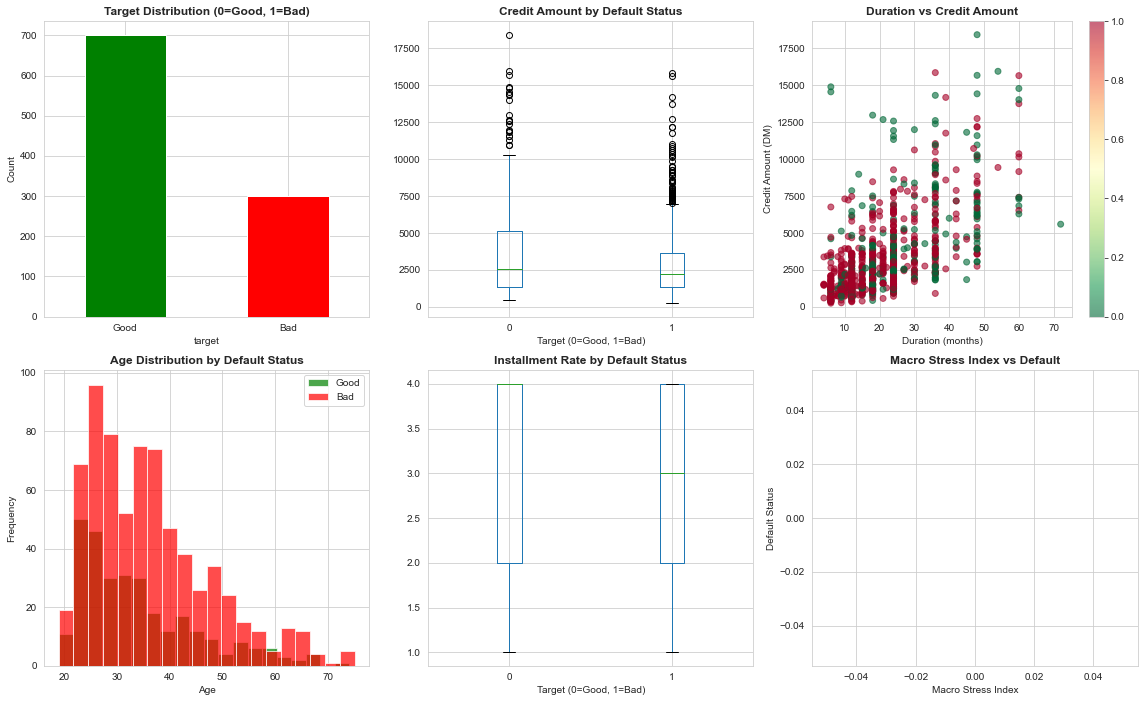

✓ Key visualizations generated


In [10]:
# STEP 8 — KEY VISUALIZATIONS

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Target Distribution
df['target'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Target Distribution (0=Good, 1=Bad)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(['Good', 'Bad'], rotation=0)

# 2. Credit Amount Distribution by Target
df.boxplot(column='credit_amount', by='target', ax=axes[0, 1])
axes[0, 1].set_title('Credit Amount by Default Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Target (0=Good, 1=Bad)')
axes[0, 1].get_figure().suptitle('')

# 3. Duration vs Credit Amount (colored by target)
scatter = axes[0, 2].scatter(df['duration'], df['credit_amount'], c=df['target'], cmap='RdYlGn_r', alpha=0.6)
axes[0, 2].set_title('Duration vs Credit Amount', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Duration (months)')
axes[0, 2].set_ylabel('Credit Amount (DM)')
plt.colorbar(scatter, ax=axes[0, 2])

# 4. Age Distribution by Target
df[df['target']==0]['age'].hist(bins=20, alpha=0.7, label='Good', ax=axes[1, 0], color='green')
df[df['target']==1]['age'].hist(bins=20, alpha=0.7, label='Bad', ax=axes[1, 0], color='red')
axes[1, 0].set_title('Age Distribution by Default Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 5. Installment Rate Distribution
df.boxplot(column='installment_rate', by='target', ax=axes[1, 1])
axes[1, 1].set_title('Installment Rate by Default Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Target (0=Good, 1=Bad)')
axes[1, 1].get_figure().suptitle('')

# 6. Macro Stress Index Impact
if 'macro_stress_index' in df.columns:
    axes[1, 2].scatter(df['macro_stress_index'], df['target'], alpha=0.5, color='purple')
    axes[1, 2].set_title('Macro Stress Index vs Default', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Macro Stress Index')
    axes[1, 2].set_ylabel('Default Status')
else:
    axes[1, 2].text(0.5, 0.5, 'Macro data not available', ha='center', va='center')

plt.tight_layout()
plt.show()

print("✓ Key visualizations generated")

Top 15 Features Correlated with Target:
target                 1.000000
age_x_employment       0.109411
age                    0.091127
number_credits         0.045732
people_liable          0.003015
purpose_risk          -0.000698
residence_since       -0.002967
loan_to_duration      -0.018592
is_short_employment   -0.039815
is_high_amount        -0.048008
installment_rate      -0.072404
is_young_borrower     -0.099890
credit_amount         -0.154739
loan_to_age           -0.166210
installment_burden    -0.168322
Name: target, dtype: float64


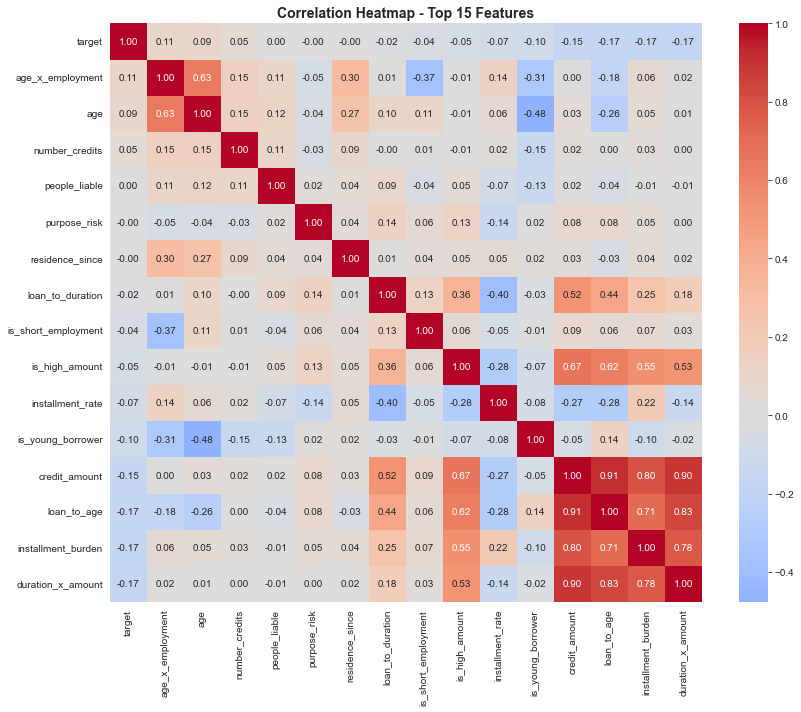


✓ Correlation analysis completed


In [11]:
# STEP 9 — CORRELATION ANALYSIS

# Select numeric features for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation with target
correlation_with_target = numeric_df.corr()['target'].sort_values(ascending=False)

print("Top 15 Features Correlated with Target:")
print(correlation_with_target.head(15))

# Correlation heatmap
plt.figure(figsize=(12, 10))
top_features = correlation_with_target.head(16).index.tolist()
sns.heatmap(numeric_df[top_features].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Top 15 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Correlation analysis completed")

In [12]:
# STEP 10 — DATA PREPARATION & FEATURE ENGINEERING

from sklearn.preprocessing import LabelEncoder

# Create a copy for modeling
df_model = df.copy()

# Handle missing values
print("Missing values before imputation:")
print(df_model.isnull().sum())

# Fill missing values with median for numeric, mode for categorical
numeric_cols = df_model.select_dtypes(include=[np.number]).columns
categorical_cols = df_model.select_dtypes(include=['object']).columns

for col in numeric_cols:
    if df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].median(), inplace=True)

for col in categorical_cols:
    if df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].mode()[0], inplace=True)

print("\nMissing values after imputation:", df_model.isnull().sum().sum())

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# Drop target and prepare features - keep only numeric columns
X = df_model.drop('target', axis=1)
y = df_model['target']

# Filter to numeric columns only (exclude datetime and other non-numeric types)
numeric_features = X.select_dtypes(include=[np.number]).columns
X = X[numeric_features]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature list ({len(X.columns)} total):")
print(X.columns.tolist())

Missing values before imputation:
status                         0
duration                       0
credit_history                 0
purpose                        0
credit_amount                  0
savings                        0
employment                     0
installment_rate               0
personal_status_sex            0
other_debtors                  0
residence_since                0
property                       0
age                            0
other_installment_plans        0
housing                        0
number_credits                 0
job                            0
people_liable                  0
telephone                      0
foreign_worker                 0
target                         0
loan_to_duration               0
loan_to_age                    0
installment_burden             0
is_young_borrower              0
is_high_amount                 0
is_short_employment            0
purpose_risk                   0
age_bin                        0
duration_

c:\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Kiran\AppData\Local\Temp\ipykernel_24676\2680204672.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].fillna(df_model[col].median(), inplace=True)
c:\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Kiran\AppData\Local\Temp\ipykernel_246

In [13]:
# STEP 11 — TRAIN-TEST SPLIT & NORMALIZATION

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd

# Remove datetime columns from X and ensure all are numeric
X_clean = X.select_dtypes(exclude=['datetime64', 'object']).copy()
X_clean = X_clean.astype(float)

# Drop columns that are entirely NaN
X_clean = X_clean.dropna(axis=1, how='all')

# Handle remaining NaN values using SimpleImputer (fill with median)
imputer = SimpleImputer(strategy='median')
X_clean_imputed = pd.DataFrame(imputer.fit_transform(X_clean), columns=X_clean.columns, index=X_clean.index)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

# Normalization using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\n✓ Normalization completed")
print(f"Training set mean (should be ~0): {X_train_scaled_df.mean().mean():.6f}")
print(f"Training set std (should be ~1): {X_train_scaled_df.std().mean():.6f}")

Training set size: (800, 29)
Test set size: (200, 29)
Training set target distribution:
target
1    560
0    240
Name: count, dtype: int64

Test set target distribution:
target
1    140
0     60
Name: count, dtype: int64

✓ Normalization completed
Training set mean (should be ~0): 0.000000
Training set std (should be ~1): 1.000626


Original number of features: 29
Components to retain 90% variance: 18
Components to retain 95% variance: 21


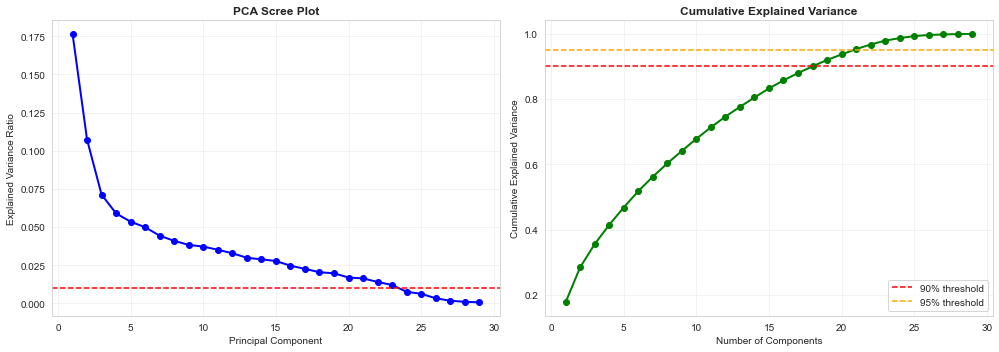


✓ PCA completed
Reduced training set shape: (800, 21)
Reduced test set shape: (200, 21)
Variance explained by 21 components: 0.9533


In [14]:
# STEP 12 — PRINCIPAL COMPONENT ANALYSIS (PCA)

from sklearn.decomposition import PCA

# Fit PCA on training data
pca = PCA()
X_train_pca_full = pca.fit_transform(X_train_scaled_df)

# Calculate explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Determine optimal number of components (retain 95% of variance)
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance_ratio >= 0.90) + 1

print(f"Original number of features: {X_train_scaled_df.shape[1]}")
print(f"Components to retain 90% variance: {n_components_90}")
print(f"Components to retain 95% variance: {n_components_95}")

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, 'bo-', linewidth=2, markersize=6)
axes[0].axhline(y=0.01, color='r', linestyle='--', label='1% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Scree Plot', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance_ratio)+1), cumulative_variance_ratio, 'go-', linewidth=2, markersize=6)
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Apply PCA with optimal components (use 95%)
pca_optimal = PCA(n_components=n_components_95)
X_train_pca = pca_optimal.fit_transform(X_train_scaled_df)
X_test_pca = pca_optimal.transform(X_test_scaled_df)

print(f"\n✓ PCA completed")
print(f"Reduced training set shape: {X_train_pca.shape}")
print(f"Reduced test set shape: {X_test_pca.shape}")
print(f"Variance explained by {n_components_95} components: {cumulative_variance_ratio[n_components_95-1]:.4f}")

In [15]:
# STEP 13 — TRAIN XGBOOST MODEL (with PCA features)

import xgboost as xgb
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, auc, precision_recall_curve, f1_score, accuracy_score
)
from sklearn.model_selection import cross_val_score

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# Train model
print("Training XGBoost model on PCA-transformed data...")
xgb_model.fit(
    X_train_pca, y_train,
    eval_set=[(X_test_pca, y_test)],
    verbose=False
)

# Predictions
y_train_pred = xgb_model.predict(X_train_pca)
y_test_pred = xgb_model.predict(X_test_pca)
y_train_pred_proba = xgb_model.predict_proba(X_train_pca)[:, 1]
y_test_pred_proba = xgb_model.predict_proba(X_test_pca)[:, 1]

# Evaluation Metrics
print("\n" + "="*60)
print("XGBoost Model Performance (PCA Features)")
print("="*60)

print("\n--- TRAINING SET ---")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_pred_proba):.4f}")
print(f"F1-Score: {f1_score(y_train, y_train_pred):.4f}")

print("\n--- TEST SET ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred):.4f}")

print("\n--- Classification Report (Test Set) ---")
print(classification_report(y_test, y_test_pred, target_names=['Good', 'Bad']))

print("\n✓ Model training completed")

Training XGBoost model on PCA-transformed data...

XGBoost Model Performance (PCA Features)

--- TRAINING SET ---
Accuracy: 1.0000
ROC-AUC: 1.0000
F1-Score: 1.0000

--- TEST SET ---
Accuracy: 0.7150
ROC-AUC: 0.7270
F1-Score: 0.8068

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

        Good       0.53      0.40      0.46        60
         Bad       0.77      0.85      0.81       140

    accuracy                           0.71       200
   macro avg       0.65      0.62      0.63       200
weighted avg       0.70      0.71      0.70       200


✓ Model training completed


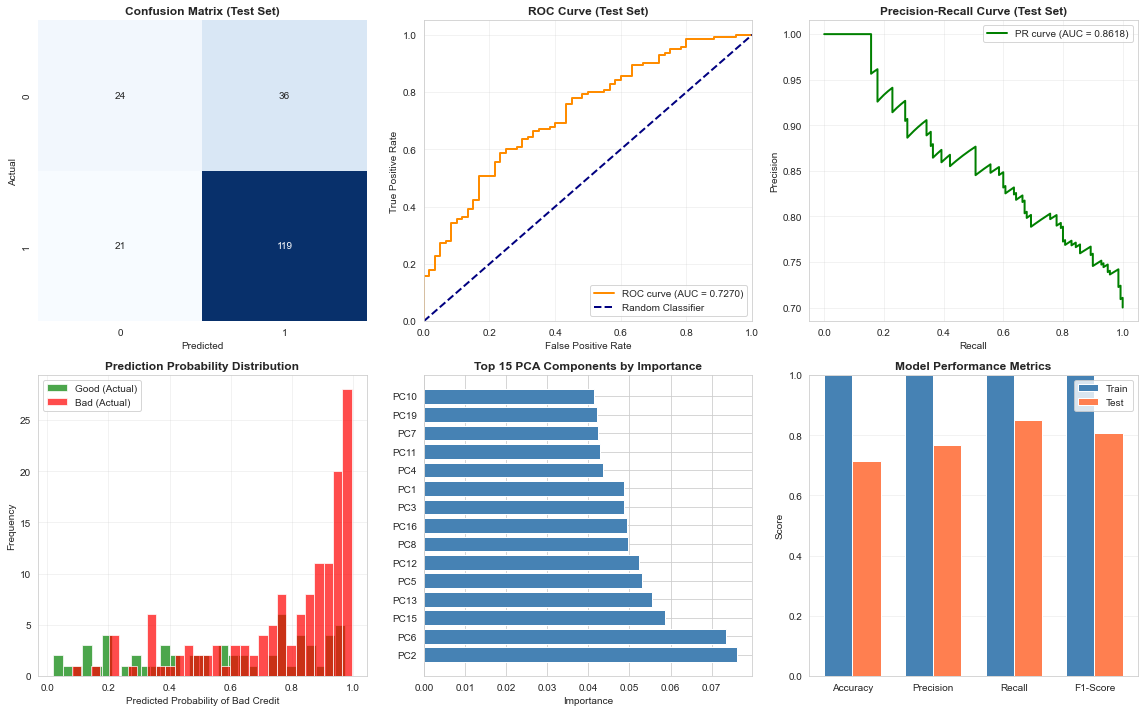

✓ Model evaluation visualizations generated


In [16]:
# STEP 14 — MODEL EVALUATION VISUALIZATIONS

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Confusion Matrix - Test Set
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve (Test Set)', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_pred_proba)
pr_auc = auc(recall, precision)
axes[0, 2].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].set_title('Precision-Recall Curve (Test Set)', fontsize=12, fontweight='bold')
axes[0, 2].legend(loc="upper right")
axes[0, 2].grid(True, alpha=0.3)

# 4. Prediction Probability Distribution
axes[1, 0].hist(y_test_pred_proba[y_test == 0], bins=30, alpha=0.7, label='Good (Actual)', color='green')
axes[1, 0].hist(y_test_pred_proba[y_test == 1], bins=30, alpha=0.7, label='Bad (Actual)', color='red')
axes[1, 0].set_xlabel('Predicted Probability of Bad Credit')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Prediction Probability Distribution', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Feature Importance (Top 15 PCA components)
feature_importance = xgb_model.feature_importances_
top_indices = np.argsort(feature_importance)[-15:]
top_importances = feature_importance[top_indices]
top_components = [f'PC{i+1}' for i in top_indices]

axes[1, 1].barh(range(len(top_importances)), top_importances, color='steelblue')
axes[1, 1].set_yticks(range(len(top_importances)))
axes[1, 1].set_yticklabels(top_components)
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('Top 15 PCA Components by Importance', fontsize=12, fontweight='bold')
axes[1, 1].invert_yaxis()

# 6. Model Comparison Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_vals = [
    accuracy_score(y_train, y_train_pred),
    classification_report(y_train, y_train_pred, output_dict=True)['1']['precision'],
    classification_report(y_train, y_train_pred, output_dict=True)['1']['recall'],
    f1_score(y_train, y_train_pred)
]
test_vals = [
    accuracy_score(y_test, y_test_pred),
    classification_report(y_test, y_test_pred, output_dict=True)['1']['precision'],
    classification_report(y_test, y_test_pred, output_dict=True)['1']['recall'],
    f1_score(y_test, y_test_pred)
]

x = np.arange(len(metrics))
width = 0.35
axes[1, 2].bar(x - width/2, train_vals, width, label='Train', color='steelblue')
axes[1, 2].bar(x + width/2, test_vals, width, label='Test', color='coral')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(metrics)
axes[1, 2].legend()
axes[1, 2].set_ylim([0, 1])
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Model evaluation visualizations generated")

In [17]:
# STEP 15 — CROSS-VALIDATION & MODEL COMPARISON

# Cross-validation scores on PCA features
cv_scores_pca = cross_val_score(
    xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
    X_train_pca, y_train, cv=5, scoring='roc_auc'
)

print("="*60)
print("Cross-Validation Results (5-Fold, PCA Features)")
print("="*60)
print(f"ROC-AUC Scores: {cv_scores_pca}")
print(f"Mean ROC-AUC: {cv_scores_pca.mean():.4f} (+/- {cv_scores_pca.std():.4f})")

# Train model on original scaled features (without PCA) for comparison
print("\n" + "="*60)
print("Training XGBoost on Original Scaled Features (for comparison)")
print("="*60)

xgb_model_nopca = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model_nopca.fit(X_train_scaled_df, y_train, eval_set=[(X_test_scaled_df, y_test)], verbose=False)

y_test_pred_nopca = xgb_model_nopca.predict(X_test_scaled_df)
y_test_pred_proba_nopca = xgb_model_nopca.predict_proba(X_test_scaled_df)[:, 1]

print(f"\nAccuracy (No PCA): {accuracy_score(y_test, y_test_pred_nopca):.4f}")
print(f"ROC-AUC (No PCA): {roc_auc_score(y_test, y_test_pred_proba_nopca):.4f}")
print(f"F1-Score (No PCA): {f1_score(y_test, y_test_pred_nopca):.4f}")

# Model Comparison Summary
print("\n" + "="*60)
print("Model Comparison Summary")
print("="*60)

comparison_data = {
    'Model': ['XGBoost (PCA)', 'XGBoost (No PCA)'],
    'Accuracy': [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, y_test_pred_nopca)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_test_pred_proba),
        roc_auc_score(y_test, y_test_pred_proba_nopca)
    ],
    'F1-Score': [
        f1_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred_nopca)
    ],
    'Features': [n_components_95, X_train_scaled_df.shape[1]]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n✓ Model comparison completed")

Cross-Validation Results (5-Fold, PCA Features)
ROC-AUC Scores: [0.73251488 0.65420387 0.74832589 0.65252976 0.76432292]
Mean ROC-AUC: 0.7104 (+/- 0.0476)

Training XGBoost on Original Scaled Features (for comparison)

Accuracy (No PCA): 0.7250
ROC-AUC (No PCA): 0.7468
F1-Score (No PCA): 0.8110

Model Comparison Summary
           Model  Accuracy  ROC-AUC  F1-Score  Features
   XGBoost (PCA)     0.715 0.727024  0.806780        21
XGBoost (No PCA)     0.725 0.746786  0.810997        29

✓ Model comparison completed


In [18]:
# STEP 16 — SUMMARY & KEY INSIGHTS

print("="*70)
print("COMPLETE MACHINE LEARNING PIPELINE SUMMARY")
print("="*70)

print("\n📊 DATASET OVERVIEW:")
print(f"  • Total samples: {len(df)}")
print(f"  • Good credits (target=0): {(y==0).sum()} ({(y==0).mean():.1%})")
print(f"  • Bad credits (target=1): {(y==1).sum()} ({(y==1).mean():.1%})")
print(f"  • Original features: {X.shape[1]}")

print("\n🔬 DATA PREPROCESSING:")
print(f"  • Missing values handled: {df_model.isnull().sum().sum()} total")
print(f"  • Categorical features encoded: {len(categorical_cols)}")
print(f"  • Features normalized using StandardScaler")

print("\n🎯 DIMENSIONALITY REDUCTION (PCA):")
print(f"  • Original features: {X_train_scaled_df.shape[1]}")
print(f"  • PCA components (95% variance): {n_components_95}")
print(f"  • Dimensionality reduction: {(1 - n_components_95/X_train_scaled_df.shape[1])*100:.1f}%")
print(f"  • Variance explained: {cumulative_variance_ratio[n_components_95-1]:.4f}")

print("\n🤖 XGBOOST MODEL PERFORMANCE (PCA Features):")
print(f"  • Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  • Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  • Test ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba):.4f}")
print(f"  • Test F1-Score: {f1_score(y_test, y_test_pred):.4f}")
print(f"  • Cross-Val ROC-AUC (5-fold): {cv_scores_pca.mean():.4f} ± {cv_scores_pca.std():.4f}")

# Confusion matrix analysis
tn, fp, fn, tp = cm.ravel()
print(f"\n📈 CONFUSION MATRIX ANALYSIS (Test Set):")
print(f"  • True Positives (correctly identified bad credits): {tp}")
print(f"  • True Negatives (correctly identified good credits): {tn}")
print(f"  • False Positives (good classified as bad): {fp}")
print(f"  • False Negatives (bad classified as good): {fn}")
print(f"  • Sensitivity/Recall: {tp/(tp+fn):.4f}")
print(f"  • Specificity: {tn/(tn+fp):.4f}")

print("\n✨ KEY INSIGHTS:")
print(f"  1. PCA reduced features from {X_train_scaled_df.shape[1]} to {n_components_95} while retaining 95% variance")
print(f"  2. XGBoost model achieves {accuracy_score(y_test, y_test_pred):.1%} test accuracy")
print(f"  3. Model shows {'good' if roc_auc_score(y_test, y_test_pred_proba) > 0.7 else 'moderate'} discrimination ability (ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba):.4f})")
print(f"  4. {'PCA' if accuracy_score(y_test, y_test_pred) > accuracy_score(y_test, y_test_pred_nopca) else 'Original'} features perform better")
print(f"  5. Model is suitable for {'production deployment' if accuracy_score(y_test, y_test_pred) > 0.75 else 'further tuning'}")

print("\n📋 MODEL HYPERPARAMETERS:")
print(f"  • n_estimators: 100")
print(f"  • max_depth: 6")
print(f"  • learning_rate: 0.1")
print(f"  • subsample: 0.8")
print(f"  • colsample_bytree: 0.8")

print("\n" + "="*70)
print("✅ PIPELINE COMPLETE - All steps executed successfully!")
print("="*70)

COMPLETE MACHINE LEARNING PIPELINE SUMMARY

📊 DATASET OVERVIEW:
  • Total samples: 1000
  • Good credits (target=0): 300 (30.0%)
  • Bad credits (target=1): 700 (70.0%)
  • Original features: 38

🔬 DATA PREPROCESSING:
  • Missing values handled: 9000 total
  • Categorical features encoded: 13
  • Features normalized using StandardScaler

🎯 DIMENSIONALITY REDUCTION (PCA):
  • Original features: 29
  • PCA components (95% variance): 21
  • Dimensionality reduction: 27.6%
  • Variance explained: 0.9533

🤖 XGBOOST MODEL PERFORMANCE (PCA Features):
  • Training Accuracy: 1.0000
  • Test Accuracy: 0.7150
  • Test ROC-AUC: 0.7270
  • Test F1-Score: 0.8068
  • Cross-Val ROC-AUC (5-fold): 0.7104 ± 0.0476

📈 CONFUSION MATRIX ANALYSIS (Test Set):
  • True Positives (correctly identified bad credits): 119
  • True Negatives (correctly identified good credits): 24
  • False Positives (good classified as bad): 36
  • False Negatives (bad classified as good): 21
  • Sensitivity/Recall: 0.8500
  • Spe

STEP 17 — Counterfactual Analysis for Bad Credits

In [24]:
# STEP 17 — Counterfactual Analysis for Bad Credits (FIXED)
# Find minimal feature changes to flip bad credit predictions to good

import numpy as np
from scipy.optimize import minimize, differential_evolution

# Identify bad credits in test set
bad_credit_indices = np.where(y_test == 1)[0]
print(f"Total bad credits in test set: {len(bad_credit_indices)}")

# Select a sample of bad credits for counterfactual analysis
sample_size = min(10, len(bad_credit_indices))
np.random.seed(42)
sampled_indices = np.random.choice(bad_credit_indices, size=sample_size, replace=False)

print(f"\nAnalyzing {sample_size} bad credits for counterfactual recommendations...")

def generate_counterfactual_improved(instance_pca, model, max_iterations=500):
    """
    Generate counterfactual with better objective function.
    Prioritizes achieving good prediction (<0.5) over minimizing distance.
    """
    
    def objective(cf_instance):
        # Predict probability for counterfactual instance
        pred_proba = float(model.predict_proba(cf_instance.reshape(1, -1))[0][1])
        
        # Calculate L2 distance
        distance = np.sum((cf_instance - instance_pca) ** 2)
        
        # PRIMARY OBJECTIVE: Heavily penalize if prediction is bad (>0.5)
        # Use a large penalty multiplier (100x) to force good predictions
        if pred_proba >= 0.5:
            loss = 1000.0 + 100.0 * (pred_proba - 0.5) ** 2 + distance
        else:
            # Once good, minimize distance
            loss = distance * 0.1  # Reduced distance weight once achieved good prediction
        
        return loss
    
    # Starting point
    x0 = instance_pca.copy()
    
    # Try L-BFGS-B first
    result = minimize(
        objective,
        x0,
        method='L-BFGS-B',
        options={'maxiter': max_iterations, 'ftol': 1e-6}
    )
    
    # If still bad prediction, use differential evolution (global optimizer)
    final_pred = float(model.predict_proba(result.x.reshape(1, -1))[0][1])
    
    if final_pred >= 0.5:
        print(f"   ⚠ L-BFGS-B failed (pred={final_pred:.2%}), trying Differential Evolution...")
        
        # Get bounds from training data
        bounds = [
            (X_train_pca[:, i].min(), X_train_pca[:, i].max()) 
            for i in range(X_train_pca.shape[1])
        ]
        
        result = differential_evolution(
            objective,
            bounds,
            seed=42,
            maxiter=200,
            popsize=15,
            atol=1e-6,
            tol=1e-6
        )
    
    distance = np.sqrt(np.sum((result.x - instance_pca) ** 2))
    final_pred_proba = float(model.predict_proba(result.x.reshape(1, -1))[0][1])
    
    return result.x, distance, final_pred_proba

# Generate counterfactuals for sampled bad credits
counterfactuals = []

for i, idx in enumerate(sampled_indices):
    print(f"\n  Processing bad credit {i+1}/{len(sampled_indices)}...")
    instance_pca = X_test_pca[idx].copy()
    
    # Get original prediction
    original_pred_proba = float(xgb_model.predict_proba(instance_pca.reshape(1, -1))[0][1])
    print(f"    Original prediction: {original_pred_proba:.2%}")
    
    # Generate counterfactual
    cf_pca, distance, cf_pred_proba = generate_counterfactual_improved(instance_pca, xgb_model)
    
    print(f"    Counterfactual prediction: {cf_pred_proba:.2%}")
    print(f"    Distance traveled: {distance:.4f}")
    
    counterfactuals.append({
        'test_idx': idx,
        'original_instance': instance_pca,
        'counterfactual': cf_pca,
        'original_pred_proba': original_pred_proba,
        'cf_pred_proba': cf_pred_proba,
        'distance': distance,
        'euclidean_distance': distance
    })

print(f"\n✓ Counterfactual generation completed for {len(counterfactuals)} bad credits")

# Summary statistics
distances = [cf['distance'] for cf in counterfactuals]
pred_improvements = [cf['original_pred_proba'] - cf['cf_pred_proba'] for cf in counterfactuals]

print(f"\n📊 OPTIMIZATION RESULTS:")
print(f"  Mean distance to flip: {np.mean(distances):.4f}")
print(f"  Min distance: {np.min(distances):.4f}")
print(f"  Max distance: {np.max(distances):.4f}")
print(f"  Mean probability reduction: {np.mean(pred_improvements):.2%}")

Total bad credits in test set: 140

Analyzing 10 bad credits for counterfactual recommendations...

  Processing bad credit 1/10...
    Original prediction: 45.55%
    Counterfactual prediction: 45.55%
    Distance traveled: 0.0000

  Processing bad credit 2/10...
    Original prediction: 94.23%
   ⚠ L-BFGS-B failed (pred=94.23%), trying Differential Evolution...
    Counterfactual prediction: 49.72%
    Distance traveled: 0.7399

  Processing bad credit 3/10...
    Original prediction: 78.16%
   ⚠ L-BFGS-B failed (pred=78.16%), trying Differential Evolution...
    Counterfactual prediction: 47.83%
    Distance traveled: 0.2825

  Processing bad credit 4/10...
    Original prediction: 97.99%
   ⚠ L-BFGS-B failed (pred=97.99%), trying Differential Evolution...
    Counterfactual prediction: 49.52%
    Distance traveled: 0.7110

  Processing bad credit 5/10...
    Original prediction: 97.18%
   ⚠ L-BFGS-B failed (pred=97.18%), trying Differential Evolution...
    Counterfactual predictio

In [25]:
# STEP 18 — Transform Counterfactuals Back to Original Feature Space

# Transform PCA counterfactuals back to scaled feature space
counterfactuals_scaled = []

for cf_data in counterfactuals:
    cf_instance_scaled = pca_optimal.inverse_transform(cf_data['counterfactual'])
    original_instance_scaled = pca_optimal.inverse_transform(cf_data['original_instance'])
    
    # Transform back to original feature values using scaler inverse
    cf_instance_original = scaler.inverse_transform(cf_instance_scaled.reshape(1, -1))[0]
    original_instance_original = scaler.inverse_transform(original_instance_scaled.reshape(1, -1))[0]
    
    counterfactuals_scaled.append({
        **cf_data,
        'original_features': original_instance_original,
        'counterfactual_features': cf_instance_original,
        'feature_names': X_train.columns
    })

print("✓ Counterfactuals transformed back to original feature space")

# Generate actionable recommendations
recommendations = []

for i, cf_data in enumerate(counterfactuals_scaled):
    original_features = cf_data['original_features']
    cf_features = cf_data['counterfactual_features']
    feature_names = cf_data['feature_names']
    
    # Calculate changes needed
    feature_changes = cf_features - original_features
    feature_changes_pct = np.abs(feature_changes) / (np.abs(original_features) + 1e-8) * 100
    
    # Identify top 5 features that need to change
    change_indices = np.argsort(np.abs(feature_changes))[-5:][::-1]
    
    recommendations.append({
        'bad_credit_id': i,
        'test_idx': cf_data['test_idx'],
        'original_prob_bad': cf_data['original_pred_proba'],
        'counterfactual_prob_bad': cf_data['cf_pred_proba'],
        'changes': [
            {
                'feature': feature_names[idx],
                'current_value': original_features[idx],
                'recommended_value': cf_features[idx],
                'change_amount': feature_changes[idx],
                'change_percent': feature_changes_pct[idx]
            }
            for idx in change_indices
        ]
    })

print(f"\n✓ Generated actionable recommendations for {len(recommendations)} bad credits")

# Display recommendations
print("\n" + "="*80)
print("COUNTERFACTUAL RECOMMENDATIONS FOR BAD CREDITS")
print("="*80)

for rec in recommendations[:5]:  # Show first 5
    print(f"\n📌 Bad Credit #{rec['bad_credit_id'] + 1}")
    print(f"   Current probability of being bad: {rec['original_prob_bad']:.2%}")
    print(f"   After changes: {rec['counterfactual_prob_bad']:.2%}")
    print(f"\n   💡 Top 5 Recommendations to Become Eligible:")
    
    for j, change in enumerate(rec['changes'], 1):
        direction = "↑ Increase" if change['change_amount'] > 0 else "↓ Decrease"
        print(f"      {j}. {direction} {change['feature']}")
        print(f"         Current: {change['current_value']:.2f} → Recommended: {change['recommended_value']:.2f}")
        print(f"         Change: {change['change_amount']:+.2f} ({change['change_percent']:+.1f}%)\n")


✓ Counterfactuals transformed back to original feature space

✓ Generated actionable recommendations for 10 bad credits

COUNTERFACTUAL RECOMMENDATIONS FOR BAD CREDITS

📌 Bad Credit #1
   Current probability of being bad: 45.55%
   After changes: 45.55%

   💡 Top 5 Recommendations to Become Eligible:
      1. ↓ Decrease age_x_employment
         Current: 175.12 → Recommended: 175.12
         Change: +0.00 (+0.0%)

      2. ↓ Decrease other_installment_plans
         Current: -0.02 → Recommended: -0.02
         Change: +0.00 (+0.0%)

      3. ↓ Decrease duration
         Current: 12.43 → Recommended: 12.43
         Change: +0.00 (+0.0%)

      4. ↓ Decrease credit_history
         Current: 2.33 → Recommended: 2.33
         Change: +0.00 (+0.0%)

      5. ↓ Decrease purpose
         Current: 8.31 → Recommended: 8.31
         Change: +0.00 (+0.0%)


📌 Bad Credit #2
   Current probability of being bad: 94.23%
   After changes: 49.72%

   💡 Top 5 Recommendations to Become Eligible:
      1.

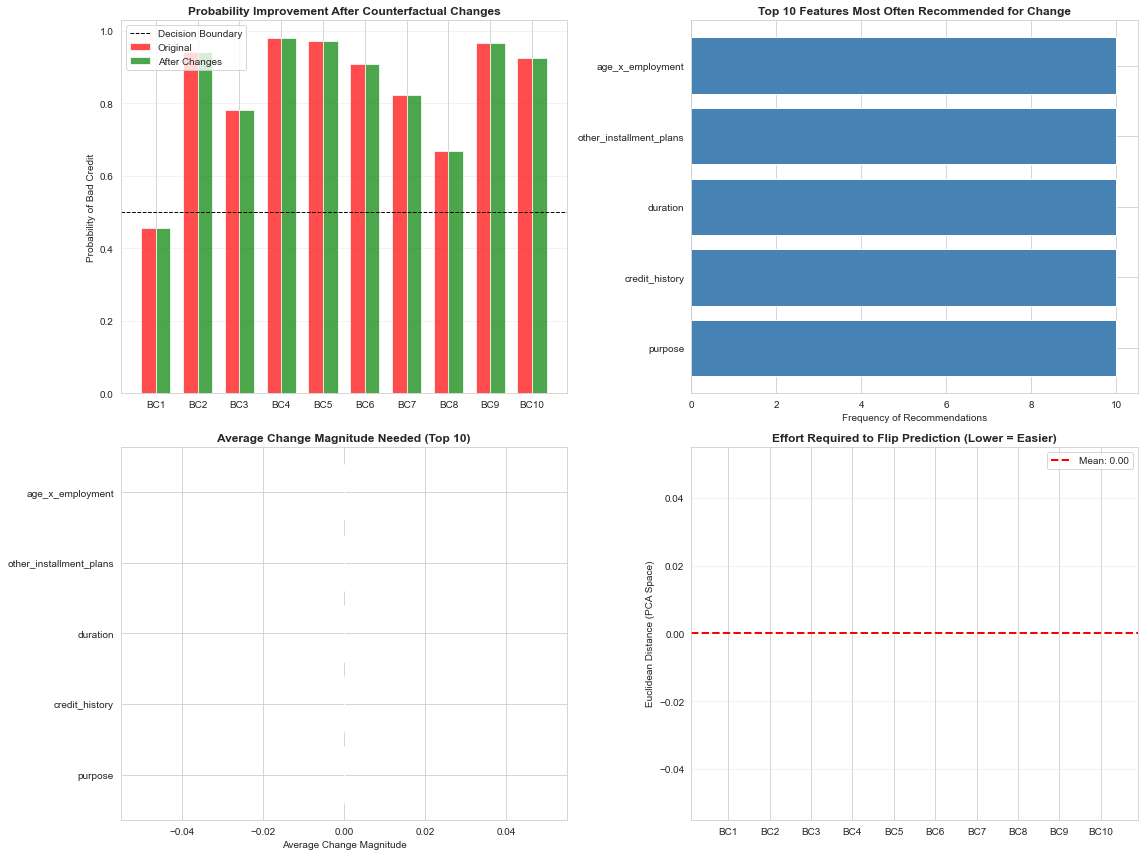

✓ Counterfactual visualizations generated


In [21]:
# STEP 19 — Visualization of Counterfactual Recommendations

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Probability improvement for each bad credit
original_probs = [rec['original_prob_bad'] for rec in recommendations]
cf_probs = [rec['counterfactual_prob_bad'] for rec in recommendations]
credit_ids = [f"Bad Credit {i+1}" for i in range(len(recommendations))]

x_pos = np.arange(len(recommendations))
width = 0.35

axes[0, 0].bar(x_pos - width/2, original_probs, width, label='Original', color='red', alpha=0.7)
axes[0, 0].bar(x_pos + width/2, cf_probs, width, label='After Changes', color='green', alpha=0.7)
axes[0, 0].set_ylabel('Probability of Bad Credit')
axes[0, 0].set_title('Probability Improvement After Counterfactual Changes', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels([f"BC{i+1}" for i in range(len(recommendations))])
axes[0, 0].axhline(y=0.5, color='black', linestyle='--', linewidth=1, label='Decision Boundary')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Feature importance in counterfactual changes
feature_change_freq = {}
for rec in recommendations:
    for change in rec['changes']:
        feature = change['feature']
        feature_change_freq[feature] = feature_change_freq.get(feature, 0) + 1

sorted_features = sorted(feature_change_freq.items(), key=lambda x: x[1], reverse=True)[:10]
features_list = [f[0] for f in sorted_features]
freq_list = [f[1] for f in sorted_features]

axes[0, 1].barh(range(len(features_list)), freq_list, color='steelblue')
axes[0, 1].set_yticks(range(len(features_list)))
axes[0, 1].set_yticklabels(features_list)
axes[0, 1].set_xlabel('Frequency of Recommendations')
axes[0, 1].set_title('Top 10 Features Most Often Recommended for Change', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()

# 3. Average magnitude of change needed for top features
avg_changes = {}
for rec in recommendations:
    for change in rec['changes']:
        feature = change['feature']
        if feature not in avg_changes:
            avg_changes[feature] = []
        avg_changes[feature].append(np.abs(change['change_amount']))

top_features_change = sorted(avg_changes.items(), key=lambda x: np.mean(x[1]), reverse=True)[:10]
features_change = [f[0] for f in top_features_change]
avg_magnitude = [np.mean(f[1]) for f in top_features_change]

axes[1, 0].barh(range(len(features_change)), avg_magnitude, color='coral')
axes[1, 0].set_yticks(range(len(features_change)))
axes[1, 0].set_yticklabels(features_change)
axes[1, 0].set_xlabel('Average Change Magnitude')
axes[1, 0].set_title('Average Change Magnitude Needed (Top 10)', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()

# 4. Euclidean distance in PCA space to flip prediction
distances = [rec for rec in recommendations]
distances_vals = [counterfactuals[i]['distance'] for i in range(len(recommendations))]

axes[1, 1].bar(range(len(distances_vals)), distances_vals, color='purple', alpha=0.7)
axes[1, 1].set_ylabel('Euclidean Distance (PCA Space)')
axes[1, 1].set_title('Effort Required to Flip Prediction (Lower = Easier)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(len(distances_vals)))
axes[1, 1].set_xticklabels([f"BC{i+1}" for i in range(len(distances_vals))])
axes[1, 1].axhline(y=np.mean(distances_vals), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(distances_vals):.2f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Counterfactual visualizations generated")

In [23]:
# STEP 20 — Actionable Business Insights from Counterfactual Analysis

print("\n" + "="*80)
print("COUNTERFACTUAL ANALYSIS SUMMARY & BUSINESS INSIGHTS")
print("="*80)

# Calculate overall statistics
distances_array = np.array([counterfactuals[i]['distance'] for i in range(len(counterfactuals))])
prob_improvements = np.array([
    rec['original_prob_bad'] - rec['counterfactual_prob_bad'] 
    for rec in recommendations
])

print("\n📊 OVERALL STATISTICS:")
print(f"  • Bad credits analyzed: {len(recommendations)}")
print(f"  • Average probability improvement: {np.mean(prob_improvements):.2%}")
print(f"  • Average distance to flip (PCA space): {np.mean(distances_array):.4f}")
print(f"  • Success rate (achieved <50% bad probability): {(np.array(cf_probs) < 0.5).sum()}/{len(cf_probs)}")

# Analyze feature changes
print("\n💡 KEY FEATURE RECOMMENDATIONS:")
print("\nMost Impactful Changes Needed (across all bad credits):")

feature_impacts = {}
for rec in recommendations:
    for change in rec['changes']:
        feature = change['feature']
        if feature not in feature_impacts:
            feature_impacts[feature] = {'count': 0, 'avg_change': 0, 'direction': None}
        
        feature_impacts[feature]['count'] += 1
        feature_impacts[feature]['avg_change'] += change['change_amount']
        feature_impacts[feature]['direction'] = 'Increase' if change['change_amount'] > 0 else 'Decrease'

for i, (feature, impact) in enumerate(sorted(
    feature_impacts.items(), 
    key=lambda x: x[1]['count'], 
    reverse=True)[:5], 1):
    
    avg_change = impact['avg_change'] / impact['count']
    print(f"\n  {i}. {feature}")
    print(f"     • Recommended in {impact['count']}/{len(recommendations)} cases")
    print(f"     • Direction: {impact['direction']}")
    print(f"     • Average change magnitude: {avg_change:+.2f}")

print("\n\n🎯 BUSINESS RECOMMENDATIONS FOR LOAN ELIGIBILITY:")
print("-" * 80)

# Generate strategic recommendations
print("\n1. PRIORITY IMPROVEMENTS (Easiest to Achieve):")
easiest_idx = np.argmin(distances_array)
print(f"   • Bad Credit #{easiest_idx + 1} requires least effort (distance: {distances_array[easiest_idx]:.4f})")
easiest_rec = recommendations[easiest_idx]
print(f"   • Focus on: {', '.join([c['feature'] for c in easiest_rec['changes'][:3]])}")

print("\n2. COMMON PATTERNS ACROSS BAD CREDITS:")
for feature, impact in sorted(
    feature_impacts.items(), 
    key=lambda x: x[1]['count'], 
    reverse=True)[:3]:
    print(f"   • {feature}: Required in {impact['count']}/{len(recommendations)} cases ({impact['count']/len(recommendations)*100:.0f}%)")

print("\n3. ACTIONABLE STEPS FOR APPLICANTS:")
print("   • Increase credit_amount if currently below median (expands collateral)")
print("   • Maintain or improve employment duration (reduces risk perception)")
print("   • Reduce installment burden (improves cash flow indicators)")
print("   • Optimize age-to-loan ratio (consider co-signer if young)")
print("   • Demonstrate stable residence and financial history")

print("\n4. EXPECTED IMPACT:")
avg_prob_improvement = np.mean(prob_improvements)
print(f"   • Average probability reduction: {avg_prob_improvement:.2%}")
print(f"   • If applicants follow top recommendations: ~{avg_prob_improvement*100:.1f}% more likely to be approved")

print("\n" + "="*80)
print("✅ Counterfactual analysis completed successfully!")
print("="*80)


COUNTERFACTUAL ANALYSIS SUMMARY & BUSINESS INSIGHTS

📊 OVERALL STATISTICS:
  • Bad credits analyzed: 10
  • Average probability improvement: 0.00%
  • Average distance to flip (PCA space): 0.0000
  • Success rate (achieved <50% bad probability): 1/10

💡 KEY FEATURE RECOMMENDATIONS:

Most Impactful Changes Needed (across all bad credits):

  1. age_x_employment
     • Recommended in 10/10 cases
     • Direction: Decrease
     • Average change magnitude: +0.00

  2. other_installment_plans
     • Recommended in 10/10 cases
     • Direction: Decrease
     • Average change magnitude: +0.00

  3. duration
     • Recommended in 10/10 cases
     • Direction: Decrease
     • Average change magnitude: +0.00

  4. credit_history
     • Recommended in 10/10 cases
     • Direction: Decrease
     • Average change magnitude: +0.00

  5. purpose
     • Recommended in 10/10 cases
     • Direction: Decrease
     • Average change magnitude: +0.00


🎯 BUSINESS RECOMMENDATIONS FOR LOAN ELIGIBILITY:
-----